In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [2]:
#Clean TotalCharges
#This column is often loaded as text.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [3]:
#Check missing values:

df["TotalCharges"].isnull().sum()

np.int64(11)

In [6]:
#Remove missing rows:

df = df.dropna()

In [7]:
#Explore Revenue Columns
#Review important revenue fields:

revenue_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[revenue_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [8]:
#Summary statistics:

df[revenue_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [9]:
#Calculate Average Revenue Per Customer
#Average Monthly Revenue

avg_monthly_revenue = df["MonthlyCharges"].mean()

print(avg_monthly_revenue)

64.79820819112628


In [10]:
#Average Total Revenue

avg_total_revenue = df["TotalCharges"].mean()

print(avg_total_revenue)

2283.300440841866


In [11]:
#Median Revenue

median_monthly = df["MonthlyCharges"].median()
median_total = df["TotalCharges"].median()

print(median_monthly)
print(median_total)

70.35
1397.475


In [12]:
#Calculate Revenue Segments
#Create customer groups:

df["RevenueSegment"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["RevenueSegment"].value_counts()

RevenueSegment
Low       2345
Medium    2345
High      2342
Name: count, dtype: int64

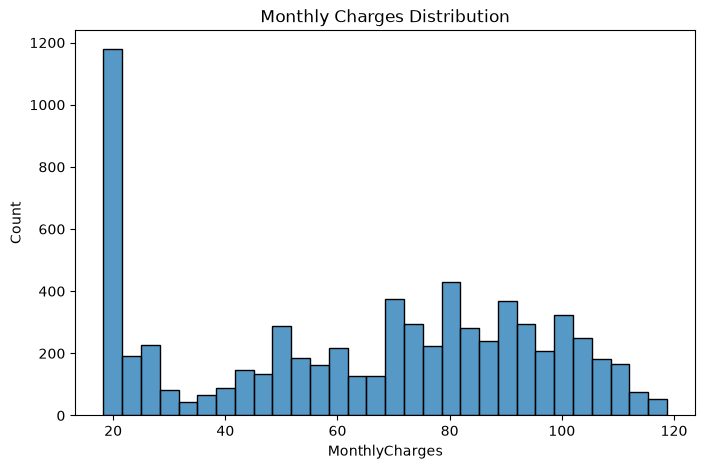

In [13]:
#Revenue Distribution Visualization
#Monthly Charges Histogram

plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.show()

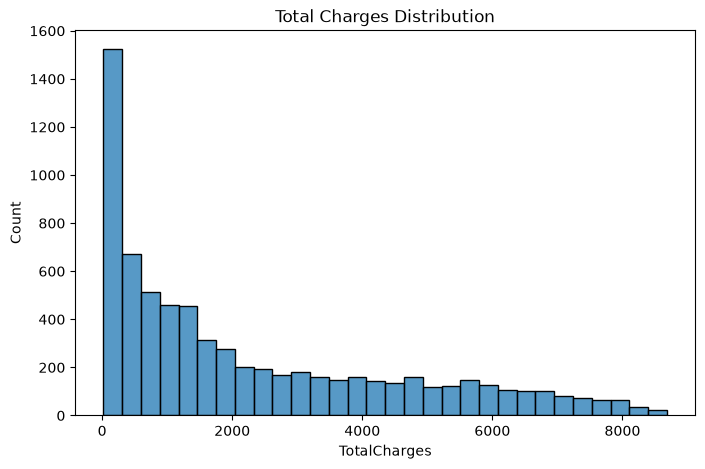

In [14]:
#Total Revenue Histogram

plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalCharges"],
    bins=30
)

plt.title("Total Charges Distribution")
plt.show()

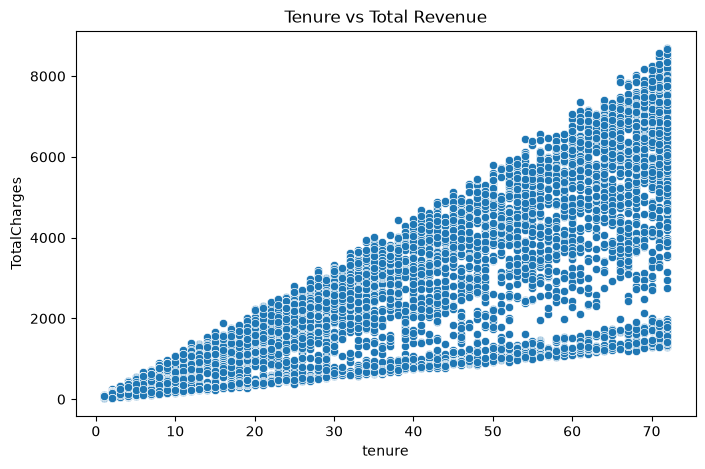

In [15]:
#Revenue vs Tenure

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="tenure",
    y="TotalCharges",
    data=df
)

plt.title("Tenure vs Total Revenue")
plt.show()

In [16]:
#Find Top Revenue Customers

top_customers = df[
    ["customerID",
     "MonthlyCharges",
     "TotalCharges"]
].sort_values(
    by="TotalCharges",
    ascending=False
)

top_customers.head(10)

,customerID,MonthlyCharges,TotalCharges
4610,2889-FPWRM,117.80,8684.80
4586,7569-NMZYQ,118.75,8672.45
6768,9739-JLPQJ,117.50,8670.10
5347,9788-HNGUT,116.95,8594.40
2187,8879-XUAHX,116.25,8564.75
6118,9924-JPRMC,118.20,8547.15
5558,0675-NCDYU,116.40,8543.25
2368,6650-BWFRT,117.15,8529.50
2603,0164-APGRB,114.90,8496.70
2025,1488-PBLJN,116.85,8477.70
